In [1]:
import numpy as np
import pandas as pd
from pandas_datareader import data as wb
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
import math as m
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
%matplotlib inline

In [2]:
assets = ["AAPL", "MSFT", "JPM", "JNJ", "XOM", "^GSPC"]
data = yf.download(assets, start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  6 of 6 completed


In [3]:
print("--- Data Overview ---")
print(data.head())
print(data.info())

--- Data Overview ---
Price           Close                                                 \
Ticker           AAPL         JNJ         JPM        MSFT        XOM   
Date                                                                   
2020-01-02  72.400520  122.638237  118.430313  152.158401  53.306404   
2020-01-03  71.696640  121.218346  116.867485  150.263748  52.877850   
2020-01-06  72.267929  121.067146  116.774574  150.652191  53.283855   
2020-01-07  71.928062  121.806458  114.789307  149.278580  52.847786   
2020-01-08  73.085098  121.789680  115.684814  151.656311  52.050816   

Price                         High                                      ...  \
Ticker            ^GSPC       AAPL         JNJ         JPM        MSFT  ...   
Date                                                                    ...   
2020-01-02  3257.850098  72.460784  122.680248  118.438715  152.262607  ...   
2020-01-03  3234.850098  72.455958  122.134117  117.619343  151.523684  ...   
2020-0

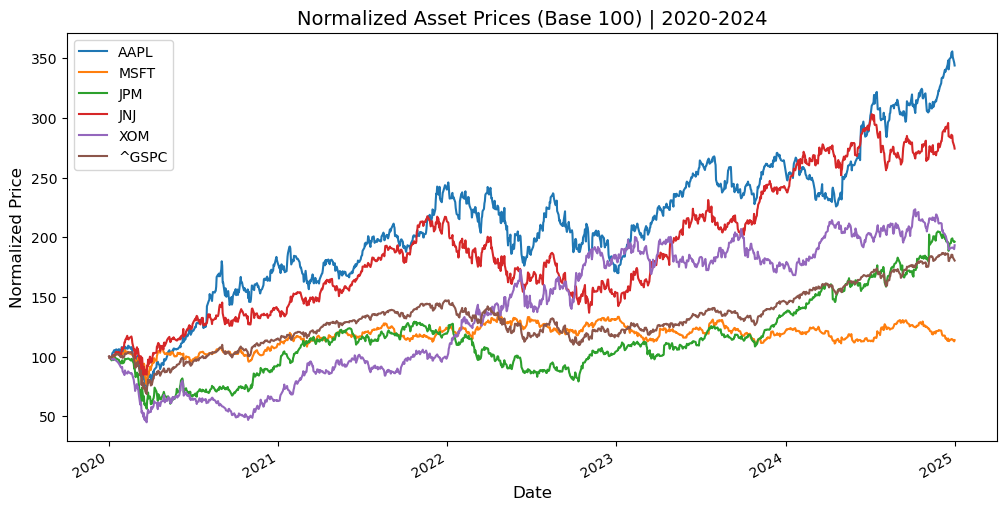

In [4]:
normalization = (data["Close"] / data["Close"].iloc[0]) * 100
normalization.plot(figsize=(12, 6))
plt.title("Normalized Asset Prices (Base 100) | 2020-2024", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price", fontsize=12)
plt.legend(assets)
plt.show()

In [5]:
log_return = np.log(data["Close"] / data["Close"].shift(1))

In [6]:
simple_returns = data["Close"].pct_change().dropna()

In [7]:
annual_returns = simple_returns.mean() * 250

In [8]:
print("\n--- Annual Returns (Asset) ---")
print(str(round(annual_returns*100,2))+"%")


--- Annual Returns (Asset) ---
Ticker
AAPL     29.55
JNJ       4.48
JPM      18.64
MSFT     24.70
XOM      18.98
^GSPC    14.02
dtype: float64%


In [9]:
stocks = ["AAPL", "MSFT", "JPM", "JNJ", "XOM"]

In [10]:
stock_annual_returns = annual_returns[stocks]

In [11]:
# Portfolio A: Equal-weight
equal_weights = np.array([0.20, 0.20, 0.20, 0.20, 0.20])

In [12]:
# Portfolio B: Conviction-based
conviction_weights = np.array([0.20, 0.10, 0.10, 0.50, 0.10])

In [13]:
portfolio_a_return = np.dot(equal_weights, stock_annual_returns)
portfolio_b_return = np.dot(conviction_weights, stock_annual_returns)

In [14]:
benchmark_return = annual_returns["^GSPC"]

In [15]:
summary_data = {
    "Portfolio A (Equal)": round(portfolio_a_return * 100, 2),
    "Portfolio B (Conviction)": round(portfolio_b_return * 100, 2),
    "Benchmark (S&P 500)": round(benchmark_return * 100, 2),
    "A vs Benchmark": round((portfolio_a_return - benchmark_return) * 100, 2),
    "B vs Benchmark": round((portfolio_b_return - benchmark_return) * 100, 2)
}

summary_df = pd.DataFrame(summary_data, index=["Annualized Return (%)"])

print("\n--- Portfolio vs Benchmark Summary ---")
print(summary_df.T)


--- Portfolio vs Benchmark Summary ---
                          Annualized Return (%)
Portfolio A (Equal)                       19.27
Portfolio B (Conviction)                  14.38
Benchmark (S&P 500)                       14.02
A vs Benchmark                             5.25
B vs Benchmark                             0.36
